In [3]:
import pandas as pd

In [5]:
df = pd.read_csv("retail project.csv")
df.head()

,Order_ID,Order_Date,Customer_Name,Region,Product,Category,Quantity,Price,Cost,Sales,Profit
0,ORD001,01-01-2024,Rahul Sharma,North,Laptop,Electronics,2,50000,40000,100000,20000
1,ORD002,03-01-2024,Priya Singh,South,Mobile Phone,Electronics,1,30000,25000,30000,5000
2,ORD003,05-01-2024,Aman Verma,East,Headphones,Electronics,3,2000,1500,6000,1500
3,ORD004,07-01-2024,Neha Gupta,West,Smart Watch,Electronics,2,8000,6000,16000,4000
4,ORD005,10-01-2024,Rohit Kumar,North,Tablet,Electronics,4,15000,12000,60000,12000


In [7]:
df = pd.read_csv("retail project.csv")

In [9]:
df.shape

(50, 11)

In [11]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'Region', 'Product',
       'Category', 'Quantity', 'Price', 'Cost', 'Sales', 'Profit'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Order_ID       50 non-null     object
 1   Order_Date     50 non-null     object
 2   Customer_Name  50 non-null     object
 3   Region         50 non-null     object
 4   Product        50 non-null     object
 5   Category       50 non-null     object
 6   Quantity       50 non-null     int64 
 7   Price          50 non-null     int64 
 8   Cost           50 non-null     int64 
 9   Sales          50 non-null     int64 
 10  Profit         50 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 4.4+ KB


In [21]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       50 non-null     object        
 1   Order_Date     50 non-null     datetime64[ns]
 2   Customer_Name  50 non-null     object        
 3   Region         50 non-null     object        
 4   Product        50 non-null     object        
 5   Category       50 non-null     object        
 6   Quantity       50 non-null     int64         
 7   Price          50 non-null     int64         
 8   Cost           50 non-null     int64         
 9   Sales          50 non-null     int64         
 10  Profit         50 non-null     int64         
dtypes: datetime64[ns](1), int64(5), object(5)
memory usage: 4.4+ KB


In [25]:
df.columns = df.columns.str.replace(" ", "_")

In [27]:
df.duplicated().sum()

0

In [29]:
df.describe()

,Order_Date,Quantity,Price,Cost,Sales,Profit
count,50,50.000000,50.000000,50.000000,50.000000,50.000000
mean,2024-03-01 18:43:12,2.520000,8672.400000,6667.200000,19480.400000,4688.200000
min,2024-01-01 00:00:00,1.000000,20.000000,10.000000,20.000000,10.000000
25%,2024-01-30 18:00:00,1.250000,1050.000000,725.000000,1900.000000,625.000000
50%,2024-03-02 00:00:00,2.000000,2100.000000,1500.000000,6000.000000,1500.000000
75%,2024-04-01 06:00:00,3.000000,8000.000000,6000.000000,20000.000000,5000.000000
max,2024-05-02 00:00:00,5.000000,50000.000000,40000.000000,135000.000000,30000.000000
std,NaN,1.297407,13597.849704,10694.700965,29968.827748,6766.965283


In [37]:
#Total sales and profit
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

Total Sales: 974020
Total Profit: 234410


In [39]:
#Sales by category

df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Electronics        586000
Home Appliances    272200
Fashion             66600
Stationery          49220
Name: Sales, dtype: int64

In [41]:
#Profit by Category

df.groupby('Category')['Profit'].sum().sort_values()

Category
Stationery          14810
Fashion             19000
Home Appliances     62200
Electronics        138400
Name: Profit, dtype: int64

In [43]:
#Region Performance

df.groupby('Region')[['Sales', 'Profit']].sum()

,Sales,Profit
Region,,
East,157400,40300
North,499420,117110
South,111200,23400
West,206000,53600


In [47]:
#Top Customers

df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending=False).head(5)

Customer_Name
Hemant Kumar       135000
Rahul Sharma       100000
Aditya Kulkarni     90000
Komal Choudhary     80000
Akash Gupta         70000
Name: Sales, dtype: int64

<Axes: xlabel='Month'>

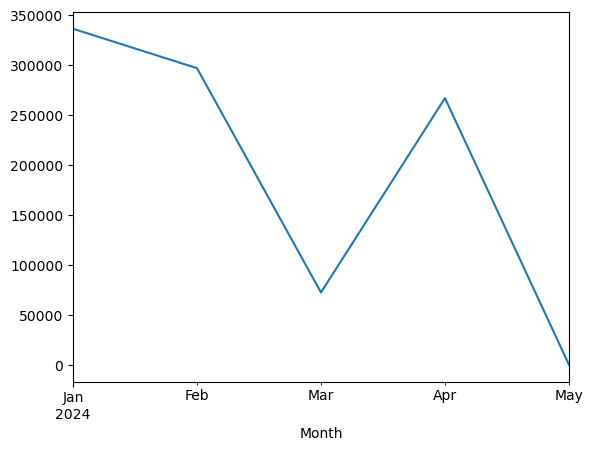

In [51]:
#Monthly Sales Trend

df['Month'] = df['Order_Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.plot()

In [53]:
#Loss Making Products

df[df['Profit'] < 0].groupby('Product')['Profit'].sum().sort_values()

Series([], Name: Profit, dtype: int64)

In [55]:
#Low Profit Products

df.sort_values(by='Profit').head(5)

,Order_ID,Order_Date,Customer_Name,Region,Product,Category,Quantity,Price,Cost,Sales,Profit,Mont,Month
32,ORD033,2024-03-20,Mohit Sharma,North,Pen,Stationery,1,20,10,20,10,2024-03,2024-03
49,ORD050,2024-05-02,Swati Kulkarni,South,Bluetooth Adapter,Electronics,1,300,200,300,100,2024-05,2024-05
37,ORD038,2024-04-02,Seema Yadav,South,Lunch Box,Stationery,2,300,200,600,200,2024-04,2024-04
36,ORD037,2024-03-30,Yogesh Pawar,North,Water Bottle,Stationery,1,500,300,500,200,2024-03,2024-03
31,ORD032,2024-03-18,Riya Sen,West,Notebook,Stationery,4,100,50,400,200,2024-03,2024-03


In [57]:
#Profit Margin

df['Profit_Margin']= df['Profit'] / df['Sales']

In [59]:
df.sort_values(by='Profit_Margin').head(5)

,Order_ID,Order_Date,Customer_Name,Region,Product,Category,Quantity,Price,Cost,Sales,Profit,Mont,Month,Profit_Margin
1,ORD002,2024-01-03,Priya Singh,South,Mobile Phone,Electronics,1,30000,25000,30000,5000,2024-01,2024-01,0.166667
21,ORD022,2024-02-22,Shweta Nair,South,Washing Machine,Home Appliances,1,30000,25000,30000,5000,2024-02,2024-02,0.166667
0,ORD001,2024-01-01,Rahul Sharma,North,Laptop,Electronics,2,50000,40000,100000,20000,2024-01,2024-01,0.200000
22,ORD023,2024-02-25,Varun Kapoor,East,Microwave,Home Appliances,3,15000,12000,45000,9000,2024-02,2024-02,0.200000
4,ORD005,2024-01-10,Rohit Kumar,North,Tablet,Electronics,4,15000,12000,60000,12000,2024-01,2024-01,0.200000
